# Embedding

We start by getting some text

In [1]:
with open("frankenstein.md", "r", encoding="utf-8") as file:
    text = file.read()

print(text[:200])

Frankenstein

The Project Gutenberg eBook of Frankenstein; Or, The Modern Prometheus

This ebook is for the use of anyone anywhere in the United States and
most other parts of the world 


If you do not have the `frankenstein.txt` file, you can download directly from Gutenberg project with the following code. It is optional, use it only if the previous code fails.

In [ ]:
import urllib.request

with urllib.request.urlopen('https://gutenberg.org/ebooks/84.txt.utf-8') as response:
   text = response.read().decode('utf-8')

text = str(text)
print(text[:200])

The Project Gutenberg eBook of Frankenstein; Or, The Modern Prometheus
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with alm


We need to separate the text into tokens. For this exercise we will take each word as a token. Let's make a function producing tokens.

In [ ]:
def tokenize(text: str) -> list[str]:
    text = text.lower()
    return text.split()

In [ ]:
tokens = tokenize(text)
print(len(tokens), tokens[:10])  # Print the first 10 tokens

In [2]:
import re

def tokenize(text: str) -> list[str]:
    pattern = re.compile(r'[\w^\']*[A-Za-z]+[\w^\']*')
    return pattern.findall(text.lower())

In [33]:
tokens = tokenize(text)
print(len(tokens), tokens[:10])  # Print the first 10 tokens

78361 ['the', 'project', 'gutenberg', 'ebook', 'of', 'frankenstein', 'or', 'the', 'modern', 'prometheus']


In [4]:
tokens = tokens[:500]  # Limit to first 10,000 tokens for faster processing

In [5]:
def mapping(tokens: list[str]) -> tuple[dict[str, int], dict[int, str]]:
    word_to_id = {}
    id_to_word = {}
    
    for i, token in enumerate(set(tokens)):
        word_to_id[token] = i
        id_to_word[i] = token
    
    return word_to_id, id_to_word

In [6]:
word_to_id, id_to_word = mapping(tokens)
word_to_id

{'no': 0,
 'petersburgh': 1,
 'has': 2,
 'preceding': 3,
 'try': 4,
 'productions': 5,
 'discovered': 6,
 'away': 7,
 'margaret': 8,
 'laws': 9,
 'phillips': 10,
 'here': 11,
 'sister': 12,
 'haines': 13,
 'by': 14,
 'my': 15,
 'country': 16,
 'where': 17,
 'shelley': 18,
 'vain': 19,
 'prometheus': 20,
 'imagination': 21,
 'there': 22,
 'united': 23,
 'braces': 24,
 'expected': 25,
 'accompanied': 26,
 'needle': 27,
 'regions': 28,
 'dec': 29,
 'an': 30,
 'frankenstein': 31,
 'welfare': 32,
 'towards': 33,
 'broad': 34,
 'or': 35,
 'land': 36,
 'contents': 37,
 'without': 38,
 'as': 39,
 'almost': 40,
 'at': 41,
 'understand': 42,
 'commencement': 43,
 'northern': 44,
 '11th': 45,
 'fervent': 46,
 'parts': 47,
 'check': 48,
 'delight': 49,
 'in': 50,
 'www': 51,
 'calm': 52,
 'attracts': 53,
 'evil': 54,
 'icy': 55,
 'corrections': 56,
 'cheeks': 57,
 'only': 58,
 'give': 59,
 'further': 60,
 'is': 61,
 'require': 62,
 'lynn': 63,
 'anywhere': 64,
 'title': 65,
 'disaster': 66,
 'stat

In [7]:
import numpy as np

def concat(*iterables):
    for iterable in iterables:
        yield from iterable

def one_hot_encode(index, vocab_size):
    one_hot = np.zeros(vocab_size)
    one_hot[index] = 1
    return one_hot

def generate_training_data(
        tokens: list[str],
        word_to_id: dict[str, int],
        window: int) -> tuple[np.ndarray, np.ndarray]:

    X = []
    y = []
    n_tokens = len(tokens)
    
    for i in range(n_tokens):
        idx = concat(
            range(max(0, i - window), i), 
            range(i, min(n_tokens, i + window + 1))
        )
        for j in idx:
            if i == j:
                continue
            X.append(one_hot_encode(word_to_id[tokens[i]], len(word_to_id)))
            y.append(one_hot_encode(word_to_id[tokens[j]], len(word_to_id)))
    
    return np.asarray(X), np.asarray(y)

In [8]:
X, y = generate_training_data(tokens, word_to_id, 2)
print(X.shape, y.shape)

(1994, 263) (1994, 263)


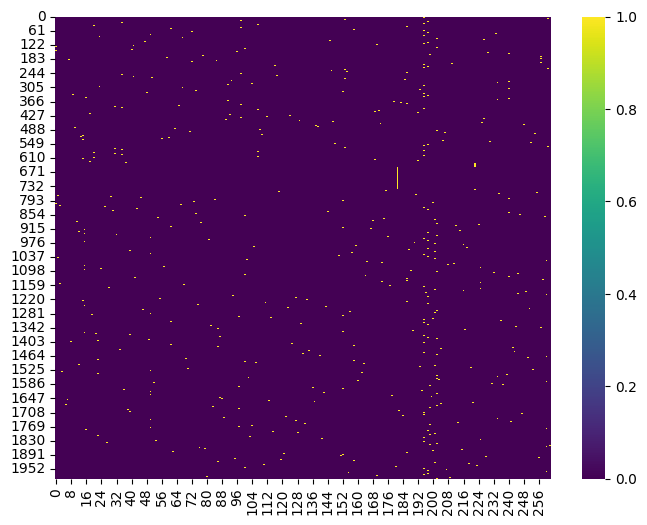

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,6))
sns.heatmap(X, cmap="viridis")
plt.show()

In [11]:
e=np.exp(X)
e

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(1994, 263))

In [12]:
s=e/np.sum(e, axis=1, keepdims=True)
s

array([[0.0037776, 0.0037776, 0.0037776, ..., 0.0037776, 0.0037776,
        0.0037776],
       [0.0037776, 0.0037776, 0.0037776, ..., 0.0037776, 0.0037776,
        0.0037776],
       [0.0037776, 0.0037776, 0.0037776, ..., 0.0037776, 0.0037776,
        0.0037776],
       ...,
       [0.0037776, 0.0037776, 0.0037776, ..., 0.0037776, 0.0037776,
        0.0037776],
       [0.0037776, 0.0037776, 0.0037776, ..., 0.0037776, 0.0037776,
        0.0037776],
       [0.0037776, 0.0037776, 0.0037776, ..., 0.0037776, 0.0037776,
        0.0037776]], shape=(1994, 263))

In [17]:
class Model:
    def __init__(self, vocab_size, n_embedding):
        self.w1 = np.random.randn(vocab_size, n_embedding)
        self.w2 = np.random.randn(n_embedding, vocab_size)

In [18]:
model = Model(len(word_to_id), 10)
model.w1.shape, model.w2.shape

((263, 10), (10, 263))

In [13]:
def softmax(X):
    res = []
    for x in X:
        exp = np.exp(x)
        res.append(exp / exp.sum())
    return res

In [14]:
def forward(model, X):
    cache = {}
    
    cache["a1"] = X @ model.w1
    cache["a2"] = cache["a1"] @ model.w2
    cache["z"] = softmax(cache["a2"])
    
    return cache

In [20]:
def cross_entropy(z, y):
    return - np.sum(np.log(z) * y)

In [15]:
def backward(model, X, y, alpha):
    cache  = forward(model, X)
    da2 = cache["z"] - y
    dw2 = cache["a1"].T @ da2
    da1 = da2 @ model.w2.T
    dw1 = X.T @ da1
    assert(dw2.shape == model.w2.shape)
    assert(dw1.shape == model.w1.shape)
    model.w1 -= alpha * dw1
    model.w2 -= alpha * dw2
    return cross_entropy(cache["z"], y)

In [24]:
a1 = X @ model.w1
a2 = a1 @ model.w2

In [25]:
a1.shape, a2.shape

((1994, 10), (1994, 263))

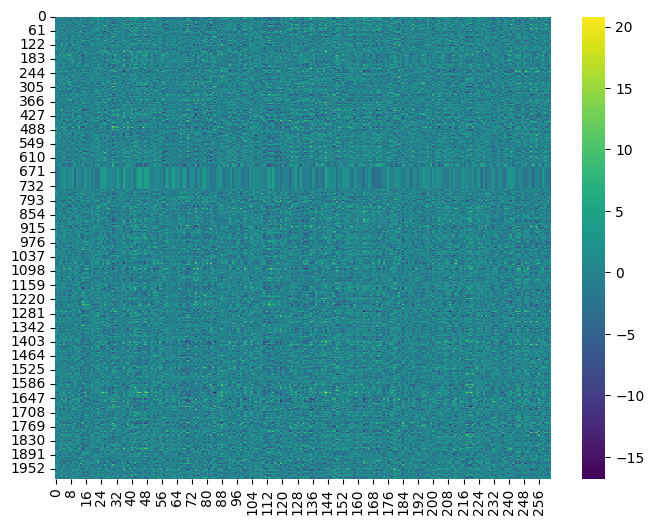

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(a2, cmap="viridis")
plt.show()

In [27]:
e = np.exp(a2)
s = e / np.sum(e, axis=1, keepdims=True)
s.shape

(1994, 263)

In [36]:
n_iter = 5
learning_rate = 0.005

history = [backward(model, X, y, learning_rate) for _ in range(n_iter)]


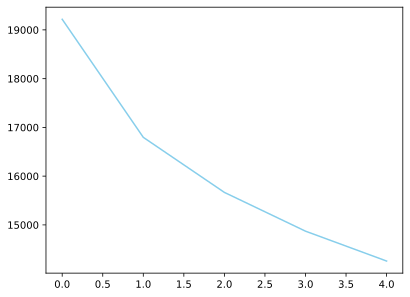

In [37]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

plt.plot(range(len(history)), history, color="skyblue")
plt.show()